TITANIC SURVIVAL PREDICTOR

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
ds = pd.read_csv('/content/Titanic-Dataset.csv')
ds.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
ds.shape

(891, 12)

In [4]:
ds.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [5]:
ds['Survived'].value_counts()

,count
Survived,
0,549
1,342


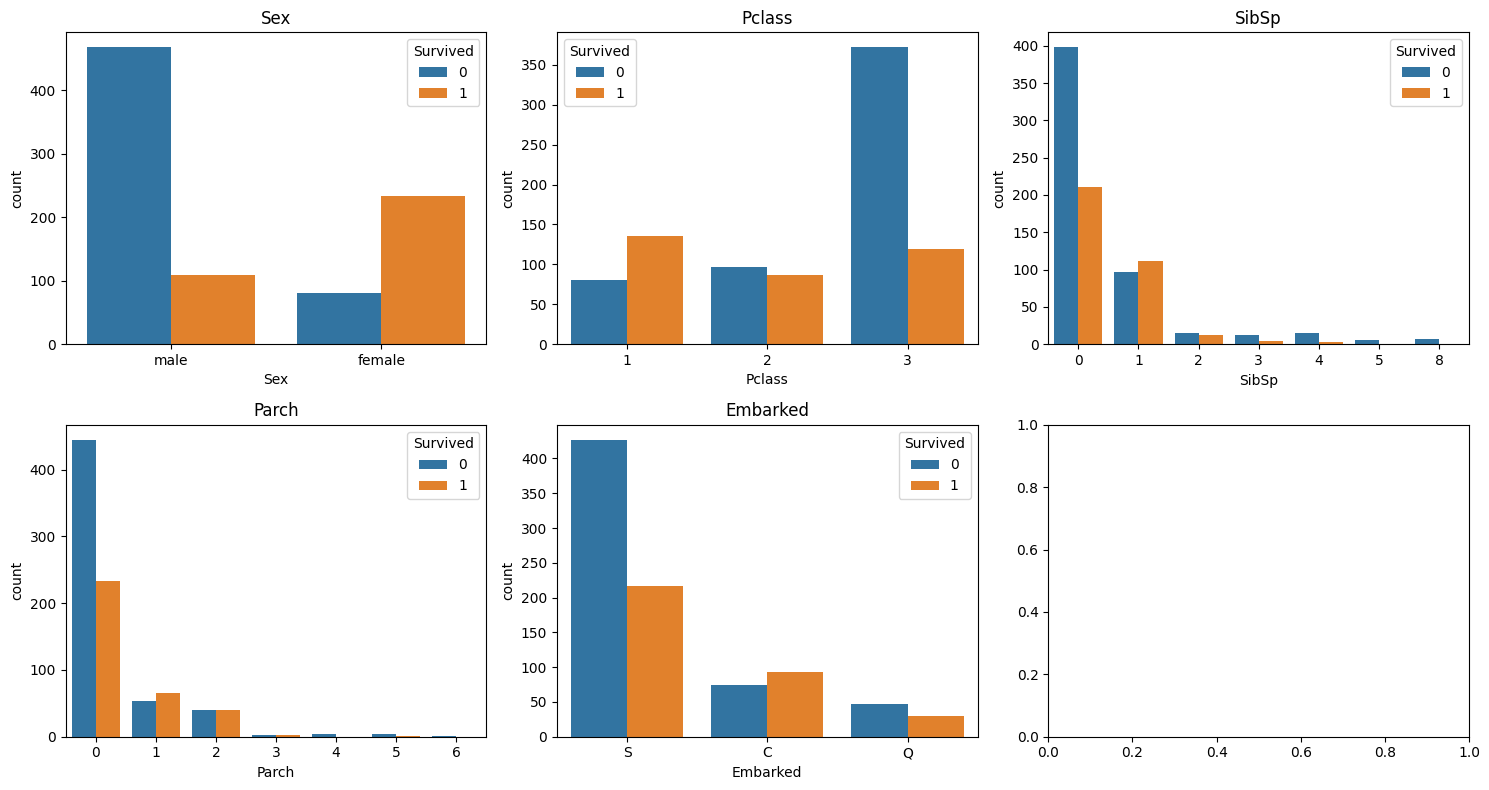

In [6]:
cols = ['Sex', 'Pclass', 'SibSp',
        'Parch', 'Embarked']

n_rows = 2
n_cols = 3

fig, axs = plt.subplots(n_rows,
                        n_cols,
                        figsize=(15, 8))

for r in range(n_rows):
    for c in range(n_cols):

        i = r * n_cols + c

        if i < len(cols):

            ax = axs[r][c]

            sns.countplot(
                x=ds[cols[i]],
                hue=ds['Survived'],
                ax=ax
            )

            ax.set_title(cols[i])

plt.tight_layout()
plt.show()

In [7]:
ds.pivot_table('Survived',index = 'Sex',columns ='Pclass')

Pclass,1,2,3
Sex,,,
female,0.968085,0.921053,0.500000
male,0.368852,0.157407,0.135447


In [8]:
ds.groupby('Sex')[('Survived')].mean()

,Survived
Sex,
female,0.742038
male,0.188908


In [3]:
from sklearn.model_selection import StratifiedShuffleSplit
split = StratifiedShuffleSplit(n_splits=1, test_size=0.2,random_state=42)
for train_index, test_index in split.split(ds, ds[['Survived','Pclass','Sex']]):
    strat_train_set = ds.loc[train_index]
    strat_test_set = ds.loc[test_index]

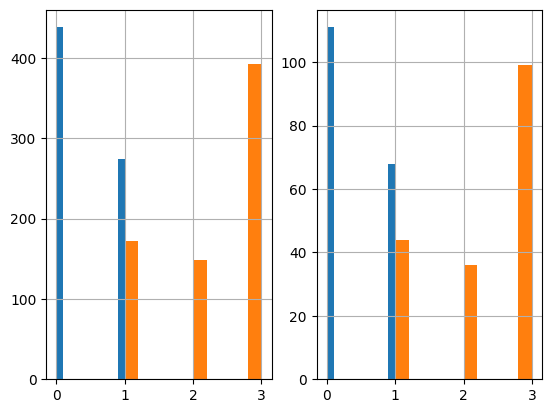

In [4]:
plt.subplot(1,2,1)
strat_train_set['Survived'].hist()
strat_train_set['Pclass'].hist()

plt.subplot(1,2,2)
strat_test_set['Survived'].hist()
strat_test_set['Pclass'].hist()

plt.show()

In [5]:
strat_train_set.info()

<class 'pandas.core.frame.DataFrame'>
Index: 712 entries, 867 to 802
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  712 non-null    int64  
 1   Survived     712 non-null    int64  
 2   Pclass       712 non-null    int64  
 3   Name         712 non-null    object 
 4   Sex          712 non-null    object 
 5   Age          565 non-null    float64
 6   SibSp        712 non-null    int64  
 7   Parch        712 non-null    int64  
 8   Ticket       712 non-null    object 
 9   Fare         712 non-null    float64
 10  Cabin        167 non-null    object 
 11  Embarked     710 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 72.3+ KB


In [7]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.impute import SimpleImputer
class AgeImputer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        imputer = SimpleImputer(strategy='mean')
        X['Age'] = imputer.fit_transform(X[['Age']])
        return X


In [8]:
from sklearn.preprocessing import OneHotEncoder
class FeatureEncoder(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        encoder = OneHotEncoder(handle_unknown='ignore')
        matrix = encoder.fit_transform(X[['Embarked']]).toarray()
        colmun_names = ['C','S','Q','N']
        for i in range(len(matrix.T)):
          X[colmun_names[i]] = matrix.T[i]

        matrix = encoder.fit_transform(X[['Sex']]).toarray()
        colmun_names = ['Female','Male']
        for i in range(len(matrix.T)):
          X[colmun_names[i]] = matrix.T[i]

        return X


In [9]:
class FeatureDropper(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        return X.drop(['Name','Ticket','Cabin','Embarked','Sex'],axis = 1)

In [10]:
from sklearn.pipeline import Pipeline
pipeline = Pipeline([('ageimputer',AgeImputer()),('featureencoder',FeatureEncoder()),('featuredropper',FeatureDropper())])

In [11]:
strat_train_set = pipeline.fit_transform(strat_train_set)

In [12]:
strat_train_set.info()

<class 'pandas.core.frame.DataFrame'>
Index: 712 entries, 867 to 802
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  712 non-null    int64  
 1   Survived     712 non-null    int64  
 2   Pclass       712 non-null    int64  
 3   Age          712 non-null    float64
 4   SibSp        712 non-null    int64  
 5   Parch        712 non-null    int64  
 6   Fare         712 non-null    float64
 7   C            712 non-null    float64
 8   S            712 non-null    float64
 9   Q            712 non-null    float64
 10  N            712 non-null    float64
 11  Female       712 non-null    float64
 12  Male         712 non-null    float64
dtypes: float64(8), int64(5)
memory usage: 77.9 KB


In [13]:
from sklearn.preprocessing import StandardScaler
X_train = strat_train_set.drop('Survived',axis = 1)
y_train = strat_train_set['Survived']
scaler = StandardScaler()
X_data = scaler.fit_transform(X_train)
y_data = y_train.to_numpy()

In [14]:
X_data

array([[ 1.6422641 , -1.56828591,  0.09549538, ..., -0.05307449,
        -0.73561236,  0.73561236],
       [ 0.67661178, -0.37019624, -0.29160547, ..., -0.05307449,
        -0.73561236,  0.73561236],
       [-1.53893728,  0.82789342, -1.7625887 , ..., -0.05307449,
        -0.73561236,  0.73561236],
       ...,
       [-1.52336225, -1.56828591,  2.72778116, ..., -0.05307449,
        -0.73561236,  0.73561236],
       [ 0.61431163,  0.82789342,  1.10195759, ..., -0.05307449,
        -0.73561236,  0.73561236],
       [ 1.38916974, -1.56828591, -1.45290802, ..., -0.05307449,
        -0.73561236,  0.73561236]])

In [15]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

clf = RandomForestClassifier()
param_grid = {
    'n_estimators': [10,100,200,500],'max_depth':[None,5,10],'min_samples_split':[2,3,4]}
grid_search = GridSearchCV(clf, param_grid, cv=3,scoring='accuracy',return_train_score=True)
grid_search.fit(X_data, y_data)

GridSearchCV(cv=3, estimator=RandomForestClassifier(),
             param_grid={'max_depth': [None, 5, 10],
                         'min_samples_split': [2, 3, 4],
                         'n_estimators': [10, 100, 200, 500]},
             return_train_score=True, scoring='accuracy')

In [16]:
final_clf = grid_search.best_estimator_
final_clf

RandomForestClassifier(max_depth=10, min_samples_split=3, n_estimators=500)

In [17]:
strat_test_set = pipeline.transform(strat_test_set)
X_test = strat_test_set.drop('Survived',axis = 1)
X_test = X_test.reindex(
    columns=X_train.columns,
    fill_value=0
)
y_test = strat_test_set['Survived']

scaler = StandardScaler()
X_test_data = scaler.fit_transform(X_test)
y_test_data = y_test.to_numpy()

/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


In [18]:
final_clf.score(X_test_data,y_test_data)

0.8324022346368715

In [19]:
final_data = pipeline.fit_transform(ds)

In [20]:
final_data

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,C,S,Q,N,Female,Male
0,1,0,3,22.000000,1,0,7.2500,0.0,0.0,1.0,0.0,0.0,1.0
1,2,1,1,38.000000,1,0,71.2833,1.0,0.0,0.0,0.0,1.0,0.0
2,3,1,3,26.000000,0,0,7.9250,0.0,0.0,1.0,0.0,1.0,0.0
3,4,1,1,35.000000,1,0,53.1000,0.0,0.0,1.0,0.0,1.0,0.0
4,5,0,3,35.000000,0,0,8.0500,0.0,0.0,1.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,27.000000,0,0,13.0000,0.0,0.0,1.0,0.0,0.0,1.0
887,888,1,1,19.000000,0,0,30.0000,0.0,0.0,1.0,0.0,1.0,0.0
888,889,0,3,29.699118,1,2,23.4500,0.0,0.0,1.0,0.0,1.0,0.0
889,890,1,1,26.000000,0,0,30.0000,1.0,0.0,0.0,0.0,0.0,1.0


In [21]:
X_final= final_data.drop('Survived',axis = 1)
y_final = final_data['Survived']
scaler = StandardScaler()
X_final_data = scaler.fit_transform(X_final)
y_final_data = y_final.to_numpy()

In [24]:
predictions = final_clf.predict(X_final_data)

In [27]:
final_df = pd.DataFrame()
final_df['PassengerId'] = ds['PassengerId']
final_df['Survived'] = predictions
final_df.to_csv('submission.csv',index = False)

In [28]:
final_df

,PassengerId,Survived
0,1,0
1,2,1
2,3,1
3,4,1
4,5,0
...,...,...
886,887,0
887,888,1
888,889,0
889,890,1
